## 1-- Choose one variable, look at its distribution (mean, sd, median, min, max), or if it is categorical, create a simple table for it, and plot it with a histogram.  Explain what you take away from looking at the variable.

In [ ]:
from __future__ import division
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import os
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
import seaborn as sns
import io


In [ ]:
url = 'https://raw.githubusercontent.com/MainakRepositor/Datasets/refs/heads/master/Webtoon%20Dataset.csv'
df = pd.read_csv(url)
df.head()

,id,Name,Writer,Likes,Genre,Rating,Subscribers,Summary,Update,Reading Link
0,0,Let's Play,Leeanne M. Krecic (Mongie),30.6M,Romance,9.62,4.2M,"She's young, single and about to achieve her d...",UP EVERY TUESDAY,https://www.webtoons.com/en/romance/letsplay/l...
1,1,True Beauty,Yaongyi,39.9M,Romance,9.60,6.4M,"After binge-watching beauty videos online, a s...",UP EVERY WEDNESDAY,https://www.webtoons.com/en/romance/truebeauty...
2,2,Midnight Poppy Land,Lilydusk,10.4M,Romance,9.81,2.1M,After making a grisly discovery in the country...,UP EVERY SATURDAY,https://www.webtoons.com/en/romance/midnight-p...
3,3,Age Matters,Enjelicious,25.9M,Romance,9.79,3.5M,She's a hopeless romantic who's turning 30's ...,UP EVERY WEDNESDAY,https://www.webtoons.com/en/romance/age-matter...
4,4,Unholy Blood,Lina Im / Jeonghyeon Kim,9.9M,Supernatural,9.85,1.5M,When vampires destroy her chance to have the n...,UP EVERY THURSDAY,https://www.webtoons.com/en/supernatural/unhol...


In [ ]:
df.Genre.value_counts().sort_index()

,count
Genre,
Action,47
Comedy,52
Drama,60
Fantasy,95
Heartwarming,2
Historical,4
Horror,20
Informative,5
Mystery,9


In [ ]:
df.Genre.value_counts(normalize=True).sort_index()*100

,proportion
Genre,
Action,8.260105
Comedy,9.138840
Drama,10.544815
Fantasy,16.695958
Heartwarming,0.351494
Historical,0.702988
Horror,3.514938
Informative,0.878735
Mystery,1.581722


<Axes: xlabel='Genre', ylabel='Count'>

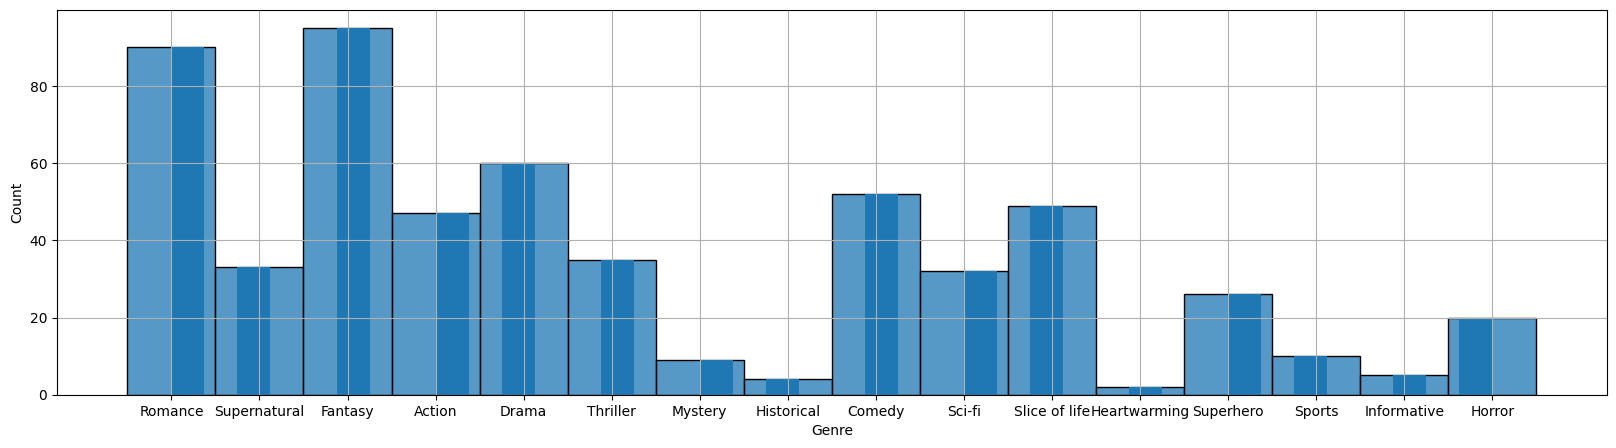

In [ ]:
sns.histplot(data=df, x="Genre")
df['Genre'].hist(bins=40, figsize=(20, 5))


There is more demand for Romance and Fantasy web comic genres on Webtoon.

## 2-- Choose some continuous-ish variable, and calculate its mean and standard deviation by some grouping variable.  Plot it using a box-plot.  Explain what conclusion you draw from this analysis.

In [ ]:
df.Subscribers.value_counts(normalize=True).sort_index()*1000000

,proportion
Subscribers,
1.1M,7029.876977
1.2M,15817.223199
1.3M,12302.284710
1.4M,3514.938489
1.5M,10544.815466
...,...
989.1K,1757.469244
99.4K,1757.469244
99.6K,1757.469244


In [ ]:
df[['Genre', 'Subscribers']].describe()

,Genre,Subscribers
count,569,569
unique,16,498
top,Fantasy,1M
freq,95,10


In [ ]:
def convert_subscribers(sub_str):
    sub_str = str(sub_str).upper()  # the data was in M (million) and K (100,000s) so i had to convert it into floats
    if 'M' in sub_str:
        return float(sub_str.replace('M', '')) * 1_000_000
    elif 'K' in sub_str:
        return float(sub_str.replace('K', '')) * 1_000
    else:
        return float(sub_str)

df['Subscribers'] = df['Subscribers'].apply(convert_subscribers)
df.groupby(['Genre'])['Subscribers'].mean()

,Subscribers
Genre,
Action,515223.404255
Comedy,375692.307692
Drama,435750.000000
Fantasy,458307.368421
Heartwarming,202950.000000
Historical,225825.000000
Horror,328480.000000
Informative,202300.000000
Mystery,320022.222222


In [ ]:
df.groupby(['Genre'])['Subscribers'].mean()

,Subscribers
Genre,
Action,515223.404255
Comedy,375692.307692
Drama,435750.000000
Fantasy,458307.368421
Heartwarming,202950.000000
Historical,225825.000000
Horror,328480.000000
Informative,202300.000000
Mystery,320022.222222


In [ ]:
df.groupby(['Genre'])['Subscribers'].std()

,Subscribers
Genre,
Action,5.083445e+05
Comedy,5.173576e+05
Drama,6.673433e+05
Fantasy,5.465074e+05
Heartwarming,2.595082e+04
Historical,3.432709e+04
Horror,2.245859e+05
Informative,1.487948e+05
Mystery,3.936653e+05


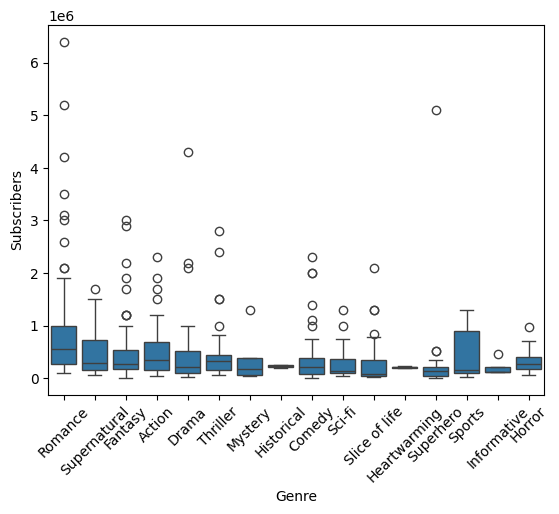

In [ ]:
sns.boxplot(data=df, x="Genre", y="Subscribers")
plt.xticks(rotation=45)  # too many genres, had to rotate the x axis
plt.show()


Romance has the highest median subscriber count. Many genres like Romance, Action, and Fantasy have many outliers. While the trend might be a certain subscriber range per genre, some titles in those categories have ammassed exceptionally high subscriber counts.

## 3-- Choose two categorical-ish variables, and cross-tabulate them.  Plot them using a stacked bar chart.  Explain what conclusion you draw from this analysis.

In [ ]:
pd.crosstab(df.Update, df.Genre, normalize='columns')*100

Genre,Action,Comedy,Drama,Fantasy,Heartwarming,Historical,Horror,Informative,Mystery,Romance,Sci-fi,Slice of life,Sports,Superhero,Supernatural,Thriller
Update,,,,,,,,,,,,,,,,
COMPLETED,21.276596,55.769231,50.000000,29.473684,0.0,25.0,55.0,80.0,33.333333,32.222222,56.250,79.591837,30.0,69.230769,51.515152,60.000000
UP EVERY FRIDAY,19.148936,7.692308,13.333333,9.473684,0.0,25.0,5.0,0.0,0.000000,6.666667,0.000,0.000000,10.0,0.000000,9.090909,2.857143
"UP EVERY MON, FRI",0.000000,1.923077,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000,0.000000,0.0,0.000000,0.000000,0.000000
"UP EVERY MON, THU",0.000000,1.923077,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000,0.000000,0.0,0.000000,0.000000,2.857143
"UP EVERY MON, TUE, WED, THU, SUN",0.000000,0.000000,0.000000,0.000000,0.0,0.0,5.0,0.0,0.000000,0.000000,0.000,0.000000,0.0,0.000000,0.000000,0.000000
"UP EVERY MON, WED",0.000000,1.923077,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000,0.000000,0.0,0.000000,0.000000,0.000000
"UP EVERY MON, WED, FRI",0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000,2.040816,0.0,0.000000,0.000000,0.000000
UP EVERY MONDAY,8.510638,1.923077,5.000000,12.631579,0.0,0.0,5.0,20.0,0.000000,13.333333,6.250,2.040816,30.0,0.000000,0.000000,0.000000
UP EVERY SATURDAY,8.510638,3.846154,6.666667,14.736842,0.0,25.0,10.0,0.0,22.222222,5.555556,6.250,0.000000,0.0,3.846154,6.060606,8.571429


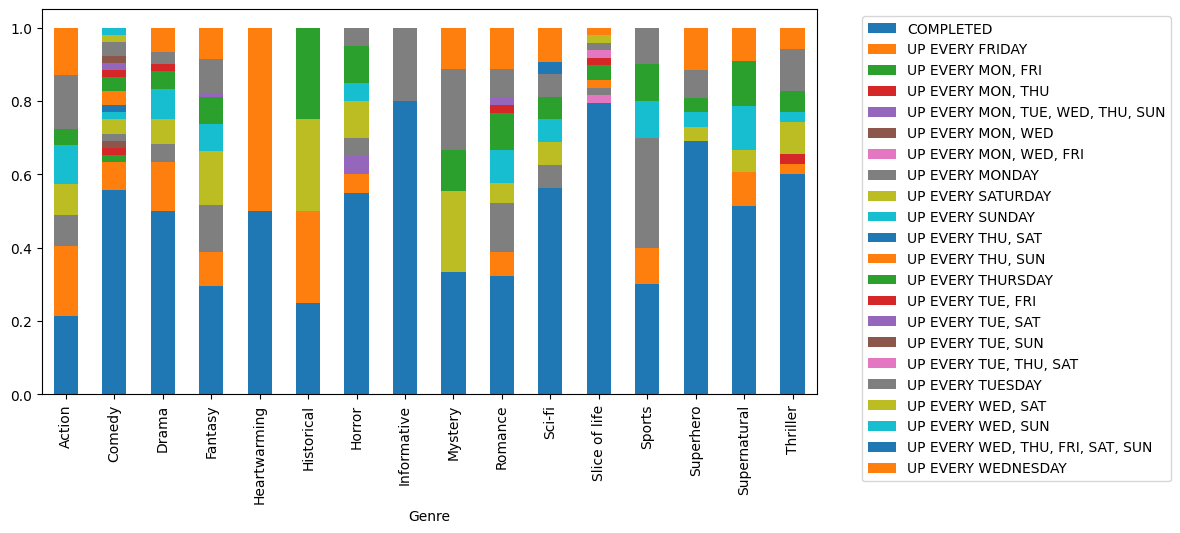

In [ ]:
Genre_Update_counts = df.groupby(['Genre', 'Update']).size()
Genre_counts = df.groupby('Genre').size()
d_pct = Genre_Update_counts / Genre_counts
d_pct.unstack().plot(kind='bar', stacked=True, figsize=(10, 5))
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1)) #legend covering graph, had to move

### Most webtoons are significantlly marked as "completed." Most webtoons have completed storylines. For the more niche genres such as Heartwarming and Historical have fewer entries due to the smaller sample size.